In [ ]:
# =========================================
# 0) INSTALLS (Colab)
# =========================================
!pip -q install albumentations==1.4.7 pycocotools timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.7/155.7 kB 15.3 MB/s eta 0:00:00


In [ ]:
# =========================================================
# CELL 2: Imports + Config
# =========================================================
import os, json, random, math
from pathlib import Path
from collections import defaultdict

import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import models
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.ops import box_iou

import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

SEED = 42
IMG_SIZE = 512
BATCH_SIZE = 4
NUM_WORKERS = 2
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

from google.colab import drive
drive.mount('/content/drive')
ROOT = Path("/content/drive/MyDrive/bm616/data")   # <-- change if needed
DATASET_NAME = "stenosis"                            # "stenosis" or "syntax"

# epochs
EPOCHS_SEGCLS = 10
EPOCHS_DET = 10

# loss weights for seg+cls
LAMBDA_SEG = 1.0
LAMBDA_CLS = 0.2

print("Device:", DEVICE)

def seed_all(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_all(SEED)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


In [ ]:
# =========================================================
# CELL 3: COCO utilities
# =========================================================
def load_coco(split):
    ann_path = ROOT / DATASET_NAME / split / "annotations" / f"{split}.json"
    img_dir = ROOT / DATASET_NAME / split / "images"
    with open(ann_path, "r") as f:
        coco = json.load(f)

    images = coco.get("images", [])
    annotations = coco.get("annotations", [])
    categories = coco.get("categories", [])

    anns_by_img = defaultdict(list)
    for a in annotations:
        anns_by_img[a["image_id"]].append(a)

    file_lookup = {im["id"]: im["file_name"] for im in images}
    return images, anns_by_img, file_lookup, img_dir, categories

def coco_poly_to_mask(anns, h, w):
    mask = np.zeros((h, w), dtype=np.uint8)
    for ann in anns:
        seg = ann.get("segmentation", [])
        if isinstance(seg, list):
            for poly in seg:
                pts = np.array(poly).reshape(-1, 2).astype(np.int32)
                if len(pts) >= 3:
                    cv2.fillPoly(mask, [pts], 1)
    return mask

def coco_bbox_xywh_to_xyxy(b):
    x, y, w, h = b
    return [x, y, x + w, y + h]


In [ ]:
# =========================================================
# CELL 4: Transforms
# =========================================================
def get_segcls_tfm(train=True):
    if train:
        return A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE),
            A.CLAHE(p=0.4),
            A.HorizontalFlip(p=0.5),
            A.ShiftScaleRotate(0.05, 0.1, 15, p=0.5),
            A.GaussNoise(p=0.2),
            A.Normalize(mean=(0.5,0.5,0.5), std=(0.5,0.5,0.5)),
            ToTensorV2()
        ])
    else:
        return A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE),
            A.Normalize(mean=(0.5,0.5,0.5), std=(0.5,0.5,0.5)),
            ToTensorV2()
        ])

# detection tfm with bbox support
def get_det_tfm(train=True):
    if train:
        return A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE),
            A.HorizontalFlip(p=0.5),
            A.ShiftScaleRotate(0.05, 0.1, 10, p=0.4),
        ], bbox_params=A.BboxParams(format="pascal_voc", label_fields=["labels"], min_visibility=0.1))
    else:
        return A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE),
        ], bbox_params=A.BboxParams(format="pascal_voc", label_fields=["labels"], min_visibility=0.1))


In [ ]:
# =========================================================
# CELL 5: Dataset for Seg + Cls
# =========================================================
class SegClsDataset(Dataset):
    def __init__(self, split):
        self.images, self.anns_by_img, self.lookup, self.img_dir, _ = load_coco(split)
        self.tfm = get_segcls_tfm(train=(split=="train"))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        item = self.images[idx]
        img_id = item["id"]

        img_path = self.img_dir / self.lookup[img_id]
        gray = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if gray is None:
            raise FileNotFoundError(str(img_path))

        anns = self.anns_by_img.get(img_id, [])
        mask = coco_poly_to_mask(anns, gray.shape[0], gray.shape[1])
        cls_label = 1.0 if len(anns) > 0 else 0.0

        img3 = np.stack([gray, gray, gray], axis=-1)

        aug = self.tfm(image=img3, mask=mask)
        x = aug["image"].float()
        y_seg = aug["mask"].unsqueeze(0).float()
        y_cls = torch.tensor(cls_label, dtype=torch.float32)

        return x, y_seg, y_cls


In [ ]:
# =========================================================
# CELL 6: Model for Seg + Cls
# =========================================================
class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, 2, 2)
        self.conv = nn.Sequential(
            nn.Conv2d(out_ch + skip_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)

class SegClsNet(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

        self.stem = nn.Sequential(base.conv1, base.bn1, base.relu)  # /2
        self.pool = base.maxpool                                    # /4
        self.e1 = base.layer1                                       # 256
        self.e2 = base.layer2                                       # 512
        self.e3 = base.layer3                                       # 1024
        self.e4 = base.layer4                                       # 2048

        # cls
        self.cls_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(2048, 1)
        )

        # seg decoder
        self.d3 = DecoderBlock(2048, 1024, 512)
        self.d2 = DecoderBlock(512, 512, 256)
        self.d1 = DecoderBlock(256, 256, 128)
        self.d0 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 2, 2),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.seg_out = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        s = self.stem(x)
        p = self.pool(s)
        f1 = self.e1(p)
        f2 = self.e2(f1)
        f3 = self.e3(f2)
        f4 = self.e4(f3)

        cls_logit = self.cls_head(f4).squeeze(1)

        z = self.d3(f4, f3)
        z = self.d2(z, f2)
        z = self.d1(z, f1)
        z = self.d0(z)
        seg_logit = self.seg_out(z)
        seg_logit = F.interpolate(seg_logit, size=x.shape[-2:], mode="bilinear", align_corners=False)

        return cls_logit, seg_logit

def dice_loss(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits)
    inter = (probs * targets).sum(dim=(1,2,3))
    union = probs.sum(dim=(1,2,3)) + targets.sum(dim=(1,2,3))
    dice = (2*inter + eps)/(union + eps)
    return 1.0 - dice.mean()

def segcls_total_loss(cls_logit, seg_logit, y_cls, y_seg, bce_cls, bce_seg):
    l_cls = bce_cls(cls_logit, y_cls)
    l_seg = 0.5*bce_seg(seg_logit, y_seg) + 0.5*dice_loss(seg_logit, y_seg)
    total = LAMBDA_CLS*l_cls + LAMBDA_SEG*l_seg
    return total, l_cls.item(), l_seg.item()


In [ ]:
# =========================================================
# CELL 7: Train/Val functions for Seg+Cls
# =========================================================
def run_segcls_epoch(model, loader, optimizer, bce_cls, bce_seg, train=True):
    if train:
        model.train()
    else:
        model.eval()

    total, cls_l, seg_l = 0.0, 0.0, 0.0
    preds_all, tgts_all = [], []

    for i, (x, y_seg, y_cls) in enumerate(loader):
        x = x.to(DEVICE, non_blocking=True)
        y_seg = y_seg.to(DEVICE, non_blocking=True)
        y_cls = y_cls.to(DEVICE, non_blocking=True)

        with torch.set_grad_enabled(train):
            cls_logit, seg_logit = model(x)
            loss, lcls, lseg = segcls_total_loss(cls_logit, seg_logit, y_cls, y_seg, bce_cls, bce_seg)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        total += loss.item()
        cls_l += lcls
        seg_l += lseg

        p = (torch.sigmoid(cls_logit) > 0.5).int().detach().cpu().numpy()
        t = y_cls.int().detach().cpu().numpy()
        preds_all.extend(p)
        tgts_all.extend(t)

        if train and i % 25 == 0:
            print(f"[train] batch {i}/{len(loader)} loss={loss.item():.4f} cls={lcls:.4f} seg={lseg:.4f}", flush=True)

    preds_all = np.array(preds_all)
    tgts_all = np.array(tgts_all)
    acc = (preds_all == tgts_all).mean() if len(tgts_all) else 0.0
    cm = confusion_matrix(tgts_all, preds_all, labels=[0,1])
    p, r, f1, _ = precision_recall_fscore_support(tgts_all, preds_all, average="binary", zero_division=0)

    n = max(1, len(loader))
    return total/n, cls_l/n, seg_l/n, acc, p, r, f1, cm

In [ ]:
# =========================================================
# CELL 8: Train Seg+Cls
# =========================================================
train_segcls = SegClsDataset("train")
val_segcls   = SegClsDataset("val")

train_loader_segcls = DataLoader(train_segcls, batch_size=BATCH_SIZE, shuffle=True,
                                 num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=(NUM_WORKERS>0))
val_loader_segcls = DataLoader(val_segcls, batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=(NUM_WORKERS>0))

segcls_model = SegClsNet().to(DEVICE)
opt_segcls = torch.optim.AdamW(segcls_model.parameters(), lr=1e-4, weight_decay=1e-4)
sch_segcls = torch.optim.lr_scheduler.CosineAnnealingLR(opt_segcls, T_max=EPOCHS_SEGCLS)
bce_cls = nn.BCEWithLogitsLoss()
bce_seg = nn.BCEWithLogitsLoss()

best_val = 1e9
SEGCLS_CKPT = "/content/best_segcls.pth"

for ep in range(1, EPOCHS_SEGCLS + 1):
    tr = run_segcls_epoch(segcls_model, train_loader_segcls, opt_segcls, bce_cls, bce_seg, train=True)
    va = run_segcls_epoch(segcls_model, val_loader_segcls, None, bce_cls, bce_seg, train=False)
    sch_segcls.step()

    tr_loss, tr_cls, tr_seg, tr_acc, tr_p, tr_r, tr_f1, tr_cm = tr
    va_loss, va_cls, va_seg, va_acc, va_p, va_r, va_f1, va_cm = va

    print(f"\n[EP {ep}/{EPOCHS_SEGCLS}]"
          f"\n Train: loss={tr_loss:.4f} cls={tr_cls:.4f} seg={tr_seg:.4f} acc={tr_acc:.4f} f1={tr_f1:.4f}"
          f"\n Val  : loss={va_loss:.4f} cls={va_cls:.4f} seg={va_seg:.4f} acc={va_acc:.4f} f1={va_f1:.4f}")
    print("Val CM:\n", va_cm)

    if va_loss < best_val:
        best_val = va_loss
        torch.save(segcls_model.state_dict(), SEGCLS_CKPT)
        print("Saved:", SEGCLS_CKPT)

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 197MB/s]


[train] batch 0/250 loss=0.9585 cls=0.6524 seg=0.8280
[train] batch 25/250 loss=0.7412 cls=0.1250 seg=0.7162
[train] batch 50/250 loss=0.5703 cls=0.0355 seg=0.5632
[train] batch 75/250 loss=0.4917 cls=0.0121 seg=0.4893
[train] batch 100/250 loss=0.3900 cls=0.0099 seg=0.3881
[train] batch 125/250 loss=0.4206 cls=0.0100 seg=0.4186
[train] batch 150/250 loss=0.4399 cls=0.0192 seg=0.4361
[train] batch 175/250 loss=0.4226 cls=0.0063 seg=0.4213
[train] batch 200/250 loss=0.4592 cls=0.0116 seg=0.4569
[train] batch 225/250 loss=0.3840 cls=0.0033 seg=0.3833

[EP 1/10]
 Train: loss=0.5060 cls=0.0675 seg=0.4925 acc=0.9970 f1=0.9985
 Val  : loss=0.4036 cls=0.0042 seg=0.4028 acc=1.0000 f1=1.0000
Val CM:
 [[  0   0]
 [  0 200]]
Saved: /content/best_segcls.pth
[train] batch 0/250 loss=0.3636 cls=0.0070 seg=0.3622
[train] batch 25/250 loss=0.3830 cls=0.0214 seg=0.3787
[train] batch 50/250 loss=0.3548 cls=0.0102 seg=0.3527
[train] batch 75/250 loss=0.6729 cls=1.3423 seg=0.4045
[train] batch 100/250 los

In [ ]:
# =========================================================
# CELL 9: Detection Dataset (Faster R-CNN)
# =========================================================
class CocoDetectionDataset(Dataset):
    def __init__(self, split):
        self.images, self.anns_by_img, self.lookup, self.img_dir, _ = load_coco(split)
        self.tfm = get_det_tfm(train=(split=="train"))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        item = self.images[idx]
        img_id = item["id"]

        img_path = self.img_dir / self.lookup[img_id]
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError(str(img_path))
        img = np.stack([img, img, img], axis=-1)  # HWC RGB-like

        anns = self.anns_by_img.get(img_id, [])

        boxes = []
        labels = []
        for a in anns:
            if "bbox" in a and a["bbox"][2] > 1 and a["bbox"][3] > 1:
                boxes.append(coco_bbox_xywh_to_xyxy(a["bbox"]))
                labels.append(1)  # single object class

        # Albumentations bbox transform
        if len(boxes) == 0:
            # keep one dummy tiny box? no. Better allow empty targets.
            aug = self.tfm(image=img, bboxes=[], labels=[])
            img_aug = aug["image"]
            boxes_aug = []
            labels_aug = []
        else:
            aug = self.tfm(image=img, bboxes=boxes, labels=labels)
            img_aug = aug["image"]
            boxes_aug = aug["bboxes"]
            labels_aug = aug["labels"]

        # to tensor image [C,H,W], normalize [0,1]
        img_t = torch.tensor(img_aug).permute(2,0,1).float() / 255.0

        if len(boxes_aug) > 0:
            boxes_t = torch.tensor(boxes_aug, dtype=torch.float32)
            labels_t = torch.tensor(labels_aug, dtype=torch.int64)
            areas_t = (boxes_t[:,2]-boxes_t[:,0]) * (boxes_t[:,3]-boxes_t[:,1])
        else:
            boxes_t = torch.zeros((0,4), dtype=torch.float32)
            labels_t = torch.zeros((0,), dtype=torch.int64)
            areas_t = torch.zeros((0,), dtype=torch.float32)

        target = {
            "boxes": boxes_t,
            "labels": labels_t,
            "image_id": torch.tensor([img_id]),
            "area": areas_t,
            "iscrowd": torch.zeros((len(labels_t),), dtype=torch.int64)
        }

        return img_t, target

def det_collate_fn(batch):
    imgs, tgts = zip(*batch)
    return list(imgs), list(tgts)

In [ ]:
# =========================================================
# CELL 10: Detection model + train loop
# =========================================================
def get_frcnn_model(num_classes=2):
    # classes: background(0), lesion(1)
    model = fasterrcnn_resnet50_fpn(weights="DEFAULT")
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)
    return model

def train_det_one_epoch(model, loader, optimizer, epoch):
    model.train()
    total = 0.0
    for i, (images, targets) in enumerate(loader):
        images = [im.to(DEVICE) for im in images]
        targets = [{k:v.to(DEVICE) for k,v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total += loss.item()

        if i % 25 == 0:
            ld = {k: float(v.detach().cpu()) for k,v in loss_dict.items()}
            print(f"[DET][EP{epoch}] batch {i}/{len(loader)} total={loss.item():.4f} {ld}", flush=True)

    return total / max(1, len(loader))

@torch.no_grad()
def eval_det_simple(model, loader, score_thr=0.3, iou_thr=0.5):
    """
    Simple proxy metric:
    - for each GT image, match predicted boxes with GT by IoU>=0.5
    - compute precision/recall over all predicted and GT boxes
    """
    model.eval()
    TP, FP, FN = 0, 0, 0

    for images, targets in loader:
        images = [im.to(DEVICE) for im in images]
        outputs = model(images)

        for out, tgt in zip(outputs, targets):
            gt_boxes = tgt["boxes"].numpy() if isinstance(tgt["boxes"], torch.Tensor) else tgt["boxes"]
            pred_boxes = out["boxes"].detach().cpu().numpy()
            pred_scores = out["scores"].detach().cpu().numpy()

            keep = pred_scores >= score_thr
            pred_boxes = pred_boxes[keep]

            if len(gt_boxes) == 0 and len(pred_boxes) == 0:
                continue
            if len(gt_boxes) == 0:
                FP += len(pred_boxes)
                continue
            if len(pred_boxes) == 0:
                FN += len(gt_boxes)
                continue

            ious = box_iou(torch.tensor(pred_boxes), torch.tensor(gt_boxes)).numpy()
            matched_gt = set()
            tp_here = 0

            for i in range(ious.shape[0]):
                j = np.argmax(ious[i])
                if ious[i, j] >= iou_thr and j not in matched_gt:
                    matched_gt.add(j)
                    tp_here += 1
                else:
                    FP += 1

            TP += tp_here
            FN += (len(gt_boxes) - tp_here)

    precision = TP / (TP + FP + 1e-9)
    recall = TP / (TP + FN + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    return precision, recall, f1

In [ ]:
# =========================================================
# CELL 11: Train Detection
# =========================================================
train_det = CocoDetectionDataset("train")
val_det   = CocoDetectionDataset("val")

train_loader_det = DataLoader(train_det, batch_size=2, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True,
                              collate_fn=det_collate_fn, persistent_workers=(NUM_WORKERS>0))
val_loader_det = DataLoader(val_det, batch_size=2, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True,
                            collate_fn=det_collate_fn, persistent_workers=(NUM_WORKERS>0))

det_model = get_frcnn_model(num_classes=2).to(DEVICE)
opt_det = torch.optim.AdamW(det_model.parameters(), lr=1e-4, weight_decay=1e-4)

DET_CKPT = "/content/best_det_frcnn.pth"
best_det_f1 = -1

for ep in range(1, EPOCHS_DET + 1):
    tr_loss = train_det_one_epoch(det_model, train_loader_det, opt_det, ep)
    p, r, f1 = eval_det_simple(det_model, val_loader_det, score_thr=0.3, iou_thr=0.5)

    print(f"\n[DET EP {ep}/{EPOCHS_DET}] train_loss={tr_loss:.4f} val_precision={p:.4f} val_recall={r:.4f} val_f1={f1:.4f}")

    if f1 > best_det_f1:
        best_det_f1 = f1
        torch.save(det_model.state_dict(), DET_CKPT)
        print("Saved:", DET_CKPT)

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 196MB/s]


[DET][EP1] batch 0/500 total=1.5729 {'loss_classifier': 1.1200027465820312, 'loss_box_reg': 0.004217228852212429, 'loss_objectness': 0.42439085245132446, 'loss_rpn_box_reg': 0.02432224527001381}
[DET][EP1] batch 25/500 total=0.2438 {'loss_classifier': 0.1110294759273529, 'loss_box_reg': 0.06947203725576401, 'loss_objectness': 0.057319290935993195, 'loss_rpn_box_reg': 0.0060093943029642105}
[DET][EP1] batch 50/500 total=0.3816 {'loss_classifier': 0.17429986596107483, 'loss_box_reg': 0.16917289793491364, 'loss_objectness': 0.0325012132525444, 'loss_rpn_box_reg': 0.005658312235027552}
[DET][EP1] batch 75/500 total=0.6776 {'loss_classifier': 0.27779456973075867, 'loss_box_reg': 0.29190754890441895, 'loss_objectness': 0.09051584452390671, 'loss_rpn_box_reg': 0.01736435294151306}
[DET][EP1] batch 100/500 total=0.2630 {'loss_classifier': 0.12486914545297623, 'loss_box_reg': 0.0974297821521759, 'loss_objectness': 0.035296618938446045, 'loss_rpn_box_reg': 0.005408702418208122}
[DET][EP1] batch 

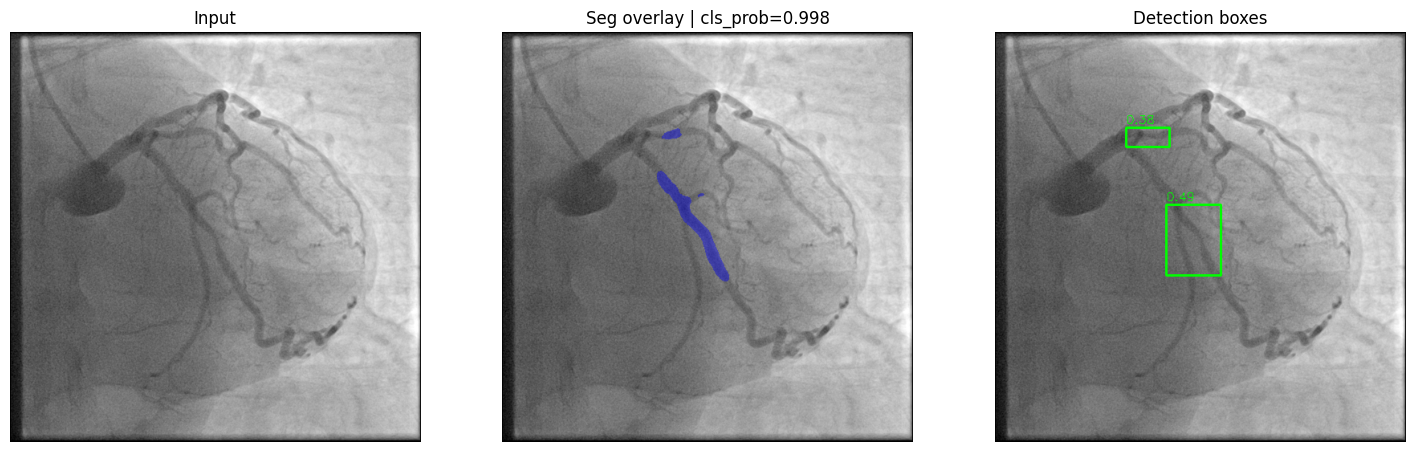

In [ ]:
# =========================================================
# CELL 12: Inference visualization (Seg+Cls + Det)
# =========================================================
def load_gray_3ch(path):
    g = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if g is None:
        raise FileNotFoundError(path)
    return np.stack([g,g,g], axis=-1)

@torch.no_grad()
def infer_segcls(model, img_bgr_or_rgb):
    tfm = A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.Normalize(mean=(0.5,0.5,0.5), std=(0.5,0.5,0.5)),
        ToTensorV2()
    ])
    aug = tfm(image=img_bgr_or_rgb)
    x = aug["image"].unsqueeze(0).to(DEVICE).float()
    cls_logit, seg_logit = model(x)
    cls_prob = torch.sigmoid(cls_logit)[0].item()
    seg_prob = torch.sigmoid(seg_logit)[0,0].cpu().numpy()
    return cls_prob, seg_prob

@torch.no_grad()
def infer_det(model, img_bgr_or_rgb, score_thr=0.3):
    img = cv2.resize(img_bgr_or_rgb, (IMG_SIZE, IMG_SIZE))
    x = torch.tensor(img).permute(2,0,1).float().to(DEVICE) / 255.0
    out = model([x])[0]
    boxes = out["boxes"].detach().cpu().numpy()
    scores = out["scores"].detach().cpu().numpy()
    keep = scores >= score_thr
    return boxes[keep], scores[keep], img

def overlay_seg_mask(img_rgb, mask_prob, thr=0.5):
    mask = (mask_prob >= thr).astype(np.uint8)
    mask_color = np.zeros_like(img_rgb)
    mask_color[..., 2] = 255
    blended = img_rgb.copy()
    blended[mask == 1] = (0.6 * blended[mask == 1] + 0.4 * mask_color[mask == 1]).astype(np.uint8)
    return blended

def draw_boxes(img_rgb, boxes, scores):
    out = img_rgb.copy()
    for b, s in zip(boxes, scores):
        x1,y1,x2,y2 = map(int, b)
        cv2.rectangle(out, (x1,y1), (x2,y2), (0,255,0), 2)
        cv2.putText(out, f"{s:.2f}", (x1, max(15,y1-5)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)
    return out

# load best models
segcls_model.load_state_dict(torch.load(SEGCLS_CKPT, map_location=DEVICE))
segcls_model.eval()

det_model.load_state_dict(torch.load(DET_CKPT, map_location=DEVICE))
det_model.eval()

# pick a sample from test
test_images, _, test_lookup, test_dir, _ = load_coco("test")
sample = test_images[0]
img_path = test_dir / test_lookup[sample["id"]]
img_rgb = load_gray_3ch(img_path)

cls_prob, seg_prob = infer_segcls(segcls_model, img_rgb)
boxes, scores, det_img = infer_det(det_model, img_rgb, score_thr=0.3)

seg_overlay = overlay_seg_mask(cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE)), seg_prob, thr=0.5)
det_overlay = draw_boxes(det_img, boxes, scores)

fig, ax = plt.subplots(1,3, figsize=(18,6))
ax[0].imshow(cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE)), cmap="gray")
ax[0].set_title("Input")
ax[1].imshow(seg_overlay)
ax[1].set_title(f"Seg overlay | cls_prob={cls_prob:.3f}")
ax[2].imshow(det_overlay)
ax[2].set_title("Detection boxes")
for a in ax: a.axis("off")
plt.show()

In [ ]:
import re

def clean_nonprintable(s):
    return ''.join(ch for ch in s if ch.isprintable() or ch in '\n\t\r')

# Example usage:
raw = """
# paste problematic code here
"""
clean = clean_nonprintable(raw)
print(clean)


# paste problematic code here



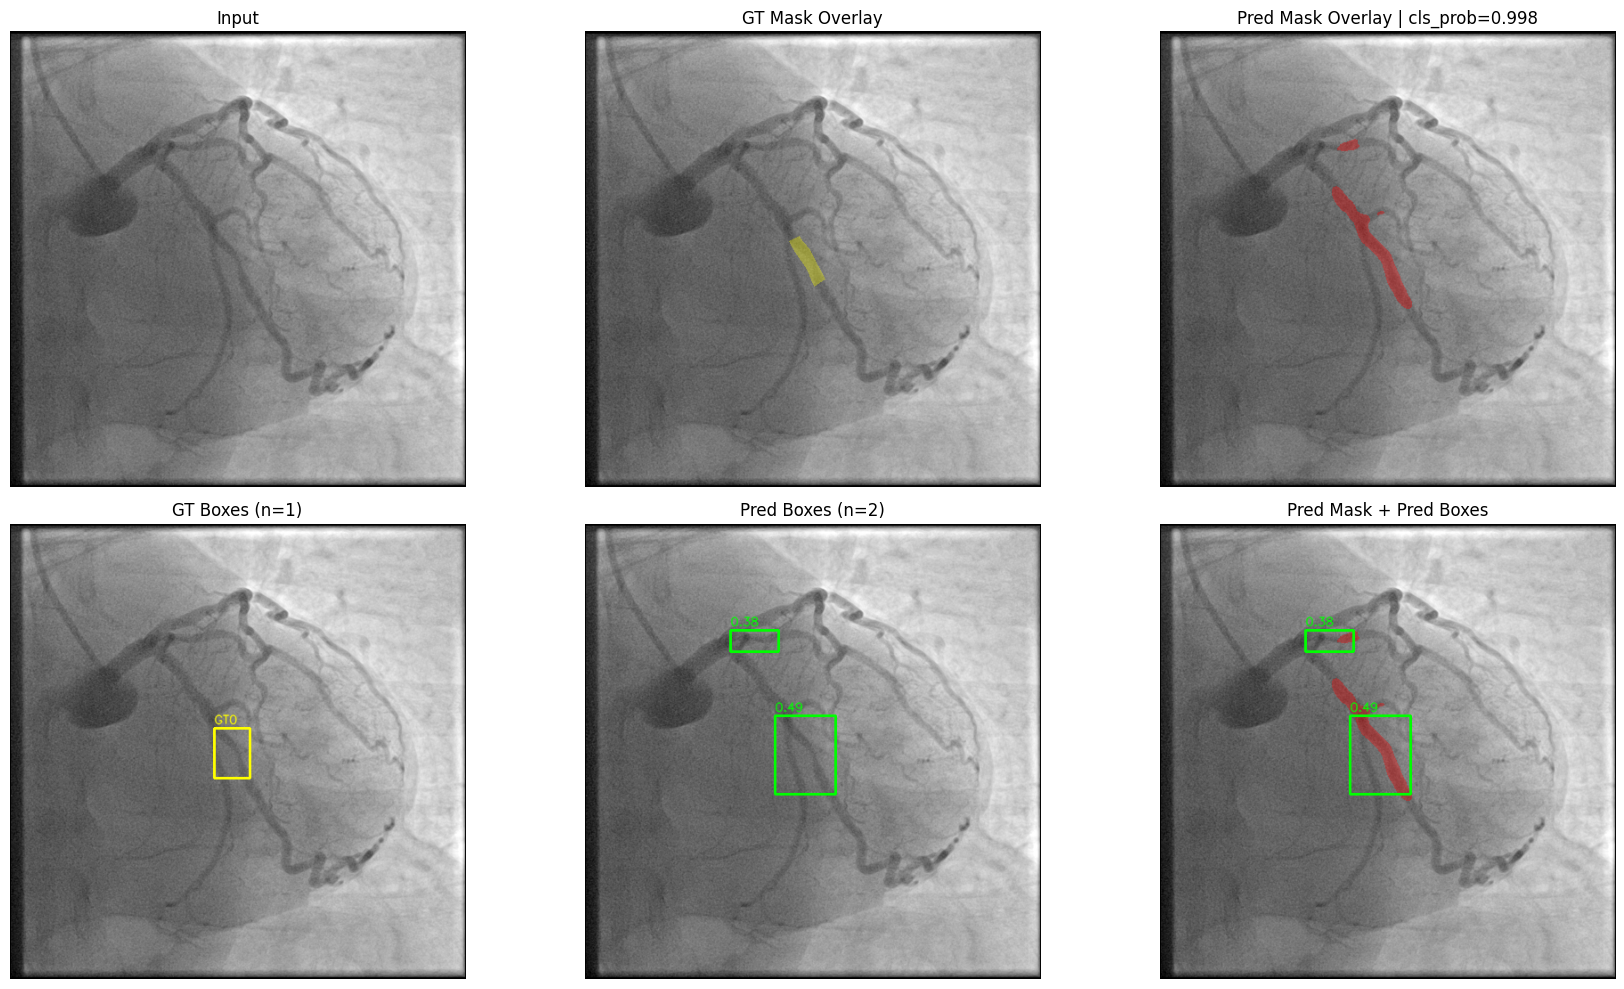

In [ ]:
# =========================================
# CELL 13 (clean): GT vs Pred visualization
# =========================================

import matplotlib.pyplot as plt
import numpy as np
import cv2
import torch
import albumentations as A
from albumentations.pytorch import ToTensorV2

def draw_boxes_np(img, boxes, color=(0,255,0), texts=None):
    out = img.copy()
    for i, b in enumerate(boxes):
        x1, y1, x2, y2 = map(int, b)
        cv2.rectangle(out, (x1,y1), (x2,y2), color, 2)
        if texts is not None and i < len(texts):
            cv2.putText(out, str(texts[i]), (x1, max(12, y1-5)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1, cv2.LINE_AA)
    return out

def overlay_mask(img, mask_bin, color=(255,0,0), alpha=0.35):
    out = img.copy()
    color_img = np.zeros_like(out)
    color_img[...,0] = color[0]
    color_img[...,1] = color[1]
    color_img[...,2] = color[2]
    m = mask_bin.astype(bool)
    out[m] = (alpha * color_img[m] + (1-alpha) * out[m]).astype(np.uint8)
    return out

def get_gt_from_coco(item, anns_by_img):
    h, w = item["height"], item["width"]
    anns = anns_by_img.get(item["id"], [])
    gt_mask = coco_poly_to_mask(anns, h, w).astype(np.uint8)

    gt_boxes = []
    for a in anns:
        if "bbox" in a and a["bbox"][2] > 1 and a["bbox"][3] > 1:
            gt_boxes.append(coco_bbox_xywh_to_xyxy(a["bbox"]))
    if len(gt_boxes) == 0:
        gt_boxes = np.zeros((0,4), dtype=np.float32)
    else:
        gt_boxes = np.array(gt_boxes, dtype=np.float32)
    return gt_mask, gt_boxes

@torch.no_grad()
def predict_segcls_on_rgb(segcls_model, img_rgb):
    tfm = A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.Normalize(mean=(0.5,0.5,0.5), std=(0.5,0.5,0.5)),
        ToTensorV2()
    ])
    x = tfm(image=img_rgb)["image"].unsqueeze(0).to(DEVICE).float()
    cls_logit, seg_logit = segcls_model(x)
    cls_prob = torch.sigmoid(cls_logit)[0].item()
    seg_prob = torch.sigmoid(seg_logit)[0,0].cpu().numpy()
    return cls_prob, seg_prob

@torch.no_grad()
def predict_det_on_rgb(det_model, img_rgb, score_thr=0.3):
    img_rs = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
    x = torch.tensor(img_rs).permute(2,0,1).float().to(DEVICE) / 255.0
    out = det_model([x])[0]
    boxes = out["boxes"].detach().cpu().numpy()
    scores = out["scores"].detach().cpu().numpy()
    keep = scores >= score_thr
    return boxes[keep], scores[keep], img_rs

# Load test set metadata
test_images, test_anns_by_img, test_lookup, test_img_dir, _ = load_coco("test")

# choose sample
idx = 0
item = test_images[idx]
img_path = test_img_dir / test_lookup[item["id"]]

g = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
if g is None:
    raise FileNotFoundError(str(img_path))
img_rgb = np.stack([g, g, g], axis=-1)

# GT
gt_mask, gt_boxes = get_gt_from_coco(item, test_anns_by_img)

# resize for visual compare
img_rs = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
gt_mask_rs = cv2.resize(gt_mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

if len(gt_boxes) > 0:
    sx = IMG_SIZE / item["width"]
    sy = IMG_SIZE / item["height"]
    gt_boxes_rs = gt_boxes.copy()
    gt_boxes_rs[:, [0,2]] *= sx
    gt_boxes_rs[:, [1,3]] *= sy
else:
    gt_boxes_rs = gt_boxes

# predictions
cls_prob, pred_seg_prob = predict_segcls_on_rgb(segcls_model, img_rgb)
pred_seg_bin = (pred_seg_prob >= 0.5).astype(np.uint8)

pred_boxes, pred_scores, det_img = predict_det_on_rgb(det_model, img_rgb, score_thr=0.3)

# overlays
gt_mask_overlay = overlay_mask(img_rs, gt_mask_rs, color=(255,255,0), alpha=0.35)
pred_mask_overlay = overlay_mask(img_rs, pred_seg_bin, color=(255,0,0), alpha=0.35)

gt_box_img = draw_boxes_np(img_rs, gt_boxes_rs, color=(255,255,0),
                           texts=[f"GT{i}" for i in range(len(gt_boxes_rs))])
pred_box_img = draw_boxes_np(det_img, pred_boxes, color=(0,255,0),
                             texts=[f"{s:.2f}" for s in pred_scores])

combined = draw_boxes_np(pred_mask_overlay, pred_boxes, color=(0,255,0),
                         texts=[f"{s:.2f}" for s in pred_scores])

fig, ax = plt.subplots(2, 3, figsize=(18,10))
ax[0,0].imshow(img_rs, cmap="gray"); ax[0,0].set_title("Input")
ax[0,1].imshow(gt_mask_overlay); ax[0,1].set_title("GT Mask Overlay")
ax[0,2].imshow(pred_mask_overlay); ax[0,2].set_title(f"Pred Mask Overlay | cls_prob={cls_prob:.3f}")
ax[1,0].imshow(gt_box_img); ax[1,0].set_title(f"GT Boxes (n={len(gt_boxes_rs)})")
ax[1,1].imshow(pred_box_img); ax[1,1].set_title(f"Pred Boxes (n={len(pred_boxes)})")
ax[1,2].imshow(combined); ax[1,2].set_title("Pred Mask + Pred Boxes")
for a in ax.ravel():
    a.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# =========================================
# CELL 14: Export artifacts after training
# =========================================
import os, json, torch

EXPORT_DIR = "/content/drive/MyDrive/bm616/model_artifacts"
os.makedirs(EXPORT_DIR, exist_ok=True)

# save weights (already done in your code, but keeping explicit)
torch.save(segcls_model.state_dict(), f"{EXPORT_DIR}/best_segcls.pth")
torch.save(det_model.state_dict(), f"{EXPORT_DIR}/best_det_frcnn.pth")

# save config for future inference
config = {
    "img_size": IMG_SIZE,
    "seg_threshold": 0.5,
    "det_score_threshold": 0.5,
    "dataset_name": DATASET_NAME,
    "device": str(DEVICE),
    "class_names": {"0": "background", "1": "lesion"}
}
with open(f"{EXPORT_DIR}/config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Saved artifacts in:", EXPORT_DIR)
print(os.listdir(EXPORT_DIR))

Saved artifacts in: /content/drive/MyDrive/bm616/model_artifacts
['best_segcls.pth', 'best_det_frcnn.pth', 'config.json']


In [ ]:
# =========================================
# CELL Y: Load models for inference (new session compatible)
# =========================================
import json
import numpy as np
import cv2
import torch
import torch.nn.functional as F
import albumentations as A
from albumentations.pytorch import ToTensorV2

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EXPORT_DIR = "/content/drive/MyDrive/bm616/model_artifacts"

with open(f"{EXPORT_DIR}/config.json", "r") as f:
    CFG = json.load(f)

IMG_SIZE = CFG["img_size"]
SEG_THR = CFG["seg_threshold"]
DET_THR = CFG["det_score_threshold"]

# --- IMPORTANT: these classes/functions must already exist in notebook ---
# SegClsNet, get_frcnn_model
# (same definitions as training notebook)

# build models
segcls_infer = SegClsNet().to(DEVICE)
segcls_infer.load_state_dict(torch.load(f"{EXPORT_DIR}/best_segcls.pth", map_location=DEVICE))
segcls_infer.eval()

det_infer = get_frcnn_model(num_classes=2).to(DEVICE)
det_infer.load_state_dict(torch.load(f"{EXPORT_DIR}/best_det_frcnn.pth", map_location=DEVICE))
det_infer.eval()

print("Models loaded.")

Models loaded.


In [ ]:
# =========================================
# CELL Z: Predict function (single image)
# =========================================
import matplotlib.pyplot as plt

def preprocess_for_segcls(img_rgb, img_size):
    tfm = A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=(0.5,0.5,0.5), std=(0.5,0.5,0.5)),
        ToTensorV2()
    ])
    x = tfm(image=img_rgb)["image"].unsqueeze(0).float().to(DEVICE)
    return x

@torch.no_grad()
def predict_image(image_path, seg_thr=0.5, det_thr=0.5, show=True, save_path=None):
    # read grayscale angiography
    g = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if g is None:
        raise FileNotFoundError(image_path)

    img_rgb = np.stack([g, g, g], axis=-1)
    img_rs = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))

    # 1) seg+cls
    x = preprocess_for_segcls(img_rgb, IMG_SIZE)
    cls_logit, seg_logit = segcls_infer(x)
    cls_prob = torch.sigmoid(cls_logit)[0].item()
    seg_prob = torch.sigmoid(seg_logit)[0,0].cpu().numpy()
    seg_bin = (seg_prob >= seg_thr).astype(np.uint8)

    # 2) detection
    det_x = torch.tensor(img_rs).permute(2,0,1).float().to(DEVICE) / 255.0
    out = det_infer([det_x])[0]
    boxes = out["boxes"].detach().cpu().numpy()
    scores = out["scores"].detach().cpu().numpy()
    keep = scores >= det_thr
    boxes = boxes[keep]
    scores = scores[keep]

    # overlays
    vis = img_rs.copy()

    # seg overlay (red)
    red = np.zeros_like(vis)
    red[..., 0] = 255
    m = seg_bin.astype(bool)
    vis[m] = (0.4 * red[m] + 0.6 * vis[m]).astype(np.uint8)

    # det boxes (green)
    for b, s in zip(boxes, scores):
        x1,y1,x2,y2 = map(int, b)
        cv2.rectangle(vis, (x1,y1), (x2,y2), (0,255,0), 2)
        cv2.putText(vis, f"{s:.2f}", (x1, max(15,y1-5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)

    result = {
        "cls_prob": float(cls_prob),
        "num_boxes": int(len(boxes)),
        "boxes": boxes.tolist(),
        "scores": scores.tolist(),
        "seg_mask": seg_bin  # numpy array
    }

    if show:
        plt.figure(figsize=(7,7))
        plt.imshow(vis, cmap="gray")
        plt.title(f"cls_prob={cls_prob:.3f} | boxes={len(boxes)}")
        plt.axis("off")
        plt.show()

    if save_path is not None:
        cv2.imwrite(save_path, cv2.cvtColor(vis, cv2.COLOR_RGB2BGR))
        print("Saved overlay:", save_path)

    return result

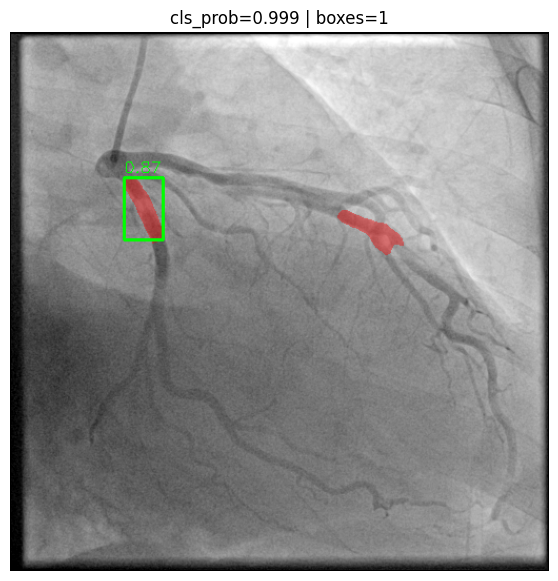

Saved overlay: /content/drive/MyDrive/bm616/pred_overlay.png
cls_prob: 0.9993415474891663
num_boxes: 1
scores: [0.8707337379455566]
seg_mask shape: (512, 512)


In [ ]:
# =========================================
# CELL W: Example call
# =========================================
test_img = "/content/drive/MyDrive/bm616/Testing/Copy of 6.png"  # change
out = predict_image(test_img, seg_thr=0.4, det_thr=0.6, show=True,
                    save_path="/content/drive/MyDrive/bm616/pred_overlay.png")

print("cls_prob:", out["cls_prob"])
print("num_boxes:", out["num_boxes"])
print("scores:", out["scores"][:5])
print("seg_mask shape:", out["seg_mask"].shape)